In [138]:
# setup
%load_ext autoreload
%autoreload 2
import logging
import os, sys
import json
from collections import defaultdict
import pandas as pd
result_dir = r'G:\python\paper_final_results\ecosystem'
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
format_str = '%(asctime)s %(levelname)s %(message)s'
formatter = logging.Formatter(fmt=format_str)
logging_file = os.path.join(
    result_dir,
    'log.log'
)
file_handler = logging.FileHandler(filename=logging_file)
file_handler.setFormatter(formatter)
file_handler.setLevel(logging.INFO)
std_handler = logging.StreamHandler(stream=sys.stdout)
std_handler.setFormatter(formatter)
std_handler.setLevel(logging.INFO)
root_logger = logging.getLogger('')
root_logger.handlers = []
root_logger.setLevel(logging.INFO)
root_logger.addHandler(std_handler)
root_logger.addHandler(file_handler)
logging.info('started')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2024-03-06 20:17:01,448 INFO started


In [139]:
# measure infiltration period of those proxy providers

#Format of collected ip information 
"""
{"Timestamp": 1701879750.0, "Response": {"ip": "113.138.149.198", "city": "Xi\u9225\u6a83n", "region": "Shaanxi", "country": "CN", "loc": "34.2583,108.9286", "org": "AS4134 CHINANET-BACKBONE", "timezone": "Asia/Shanghai", "readme": "https://ipinfo.io/missingauth"}}
"""
import json
import datetime
from collections import defaultdict

# read item from JSON file and initialize all dicts
file_path = r'C:\Users\何宁远\OneDrive\桌面\getip2.json'
with open(file_path, 'r') as file:
    data = json.load(file)
city_to_start_time_dict = {}
city_to_end_time_dict = {}
city_to_date_dict = defaultdict(set)
city_to_ip_dict = defaultdict(set)
city_request_count_dict = defaultdict(int)
provider_to_start_time_dict = {}
provider_to_end_time_dict = {}
provider_to_date_dict = defaultdict(set)
provider_to_ip_dict = defaultdict(set)
provider_request_count_dict = defaultdict(int)
# filter those items while item["Response"] is None
filtered_data = [item for item in data if item["Response"] is not None]
# iterate over each JSON item and get city dicts 
for item in filtered_data :
    timestamp = item['Timestamp']
    response = item['Response']
    ip = response['ip']
    city = response['city']
    region = response['region']
    country = response['country']
    loc = response['loc']
    org = response['org']
    timezone = response['timezone']
    readme = response['readme']
    date_str = datetime.datetime.fromtimestamp(timestamp).strftime('%Y%m%d')
    start_time = city_to_start_time_dict.get(city, None)
    end_time = city_to_end_time_dict.get(city, None)
    if start_time is None or timestamp < start_time:
        city_to_start_time_dict[city] = timestamp
    if end_time is None or timestamp > end_time:
        city_to_end_time_dict[city] = timestamp
    city_to_date_dict.setdefault(city, set()).add(date_str)
    city_to_ip_dict.setdefault(city, set()).add(ip)
    city_request_count_dict[city] += 1
    city_request_count_dict["overall"] += 1
    
# get provider dicts according to dicts acquired above
for city in city_to_start_time_dict :
    if city == "Los Angeles" :
        provider_to_ip_dict['zndata.com'] = city_to_ip_dict[city]
        provider_to_start_time_dict['zndata.com'] = city_to_start_time_dict[city]
        provider_to_end_time_dict['zndata.com'] = city_to_end_time_dict[city]
        provider_to_date_dict['zndata.com'] = city_to_date_dict[city]
        provider_request_count_dict['zndata.com'] = city_request_count_dict[city]
    else :
        start_time = provider_to_start_time_dict.get('mayivps.com', None)
        end_time = provider_to_end_time_dict.get('mayivps.com', None)
        if start_time is None or city_to_start_time_dict[city] < start_time:
            provider_to_start_time_dict['mayivps.com'] = city_to_start_time_dict[city]
        if end_time is None or city_to_end_time_dict[city] > end_time:
            provider_to_end_time_dict['mayivps.com'] = city_to_end_time_dict[city]
        provider_to_date_dict['mayivps.com'] |= city_to_date_dict[city]
        provider_to_ip_dict['mayivps.com'] |= city_to_ip_dict[city]
provider_request_count_dict['mayivps.com'] = city_request_count_dict['overall'] - city_request_count_dict['Los Angeles']
logging.info('loaded done')




2024-03-06 20:17:13,201 INFO loaded done


In [140]:
# dispaly proxy providers and their infiltration periods
date_format = '%m/%d/%Y'
import datetime
import pandas as pd
from IPython.display import display, Markdown
rows = []
overall_proxy_ips = set()
for provider in provider_to_ip_dict:
    overall_proxy_ips |= provider_to_ip_dict[provider]


for provider in provider_to_ip_dict:
    start_time = provider_to_start_time_dict[provider]
    end_time = provider_to_end_time_dict[provider]
    start_date = datetime.datetime.fromtimestamp(start_time)
    end_date = datetime.datetime.fromtimestamp(end_time)
    rows.append([
        provider,
        "{start_date} - {end_date}".format(
            start_date=start_date.strftime(date_format),
            end_date=end_date.strftime(date_format),
        ),
        len(provider_to_date_dict[provider]),
        len(provider_to_ip_dict[provider]),
        provider_request_count_dict[provider]

    ])
    
columns = ['Provider', 'Period', 'Days', 'IPs', 'Probes']
result_df = pd.DataFrame(data=rows, columns=columns)
display(Markdown('## Infiltration Periods of Proxy citys'))
display(result_df)
latex_str = result_df.to_latex(buf=None, header=False, index=False)
print(latex_str)


logging.info('done with %d ips', len(overall_proxy_ips))


## Infiltration Periods of Proxy citys

,Provider,Period,Days,IPs,Probes
0,mayivps.com,12/07/2023 - 12/24/2023,18,18277,26666
1,zndata.com,01/10/2024 - 01/15/2024,6,4673,21943


\begin{tabular}{llrrr}
\toprule
\midrule
mayivps.com & 12/07/2023 - 12/24/2023 & 18 & 18277 & 26666 \\
zndata.com & 01/10/2024 - 01/15/2024 & 6 & 4673 & 21943 \\
\bottomrule
\end{tabular}

2024-03-06 20:17:20,251 INFO done with 22950 ips


According to the table above,we can easily calculate the hit rate of each provider:68.54% of mayivps.com and 21.30% of zndata.com,which demonstrate that mayivps.com has a bigger IP pool and less repetitive IPs than zndata.com.Besides,we can acquire the rate of sending out probes:1481 and 3657 per day respectively,which prove zndata.com can collect IP quicker and has a more stable route.

In [141]:
logging.info('overall requests: %d', city_request_count_dict['overall'])

2024-03-06 20:17:20,509 INFO overall requests: 48609


In [142]:
# load in ipinfo data
ip_to_asn_dict = {}
ip_to_country_dict = {}
ip_to_geoloc_dict = {}
provider_to_asn_dict = {}
file_path = r'C:\Users\何宁远\OneDrive\桌面\getip2.json'
with open(file_path, 'r') as file:
    data = json.load(file)
filtered_data = [item for item in data if item["Response"] is not None]    
for item in filtered_data:
    timestamp = item['Timestamp']
    response = item['Response']
    ip = response['ip']
    city = response['city']
    region = response['region']
    country = response['country']
    loc = response['loc']
    org = response['org']
    timezone = response['timezone']
    readme = response['readme']
    ip_to_asn_dict.setdefault(ip, set()).add(org)
    ip_to_country_dict.setdefault(ip, set()).add(country)
    ip_to_geoloc_dict.setdefault(ip,set()).add(loc)
    if city == 'Los Angeles' :
        provider_to_asn_dict.setdefault('zndata.com',set()).add(org)
    else :
        provider_to_asn_dict.setdefault('mayivps.com',set()).add(org)

print(provider_to_asn_dict)
logging.info(
    """
    done with %d ips with asn,
    %d with country,
    %d with geoloc,
    """,
    len(ip_to_asn_dict),
    len(ip_to_country_dict),
    len(ip_to_geoloc_dict),
)

{'mayivps.com': {'AS4809 China Telecom Next Generation Carrier Network', 'AS4134 CHINANET-BACKBONE', 'AS4837 CHINA UNICOM China169 Backbone', 'AS140292 CHINATELECOM Jiangsu province Suzhou 5G network', 'AS141771 China Telecom'}, 'zndata.com': {'AS21859 Zenlayer Inc'}}
2024-03-06 20:18:26,304 INFO 
    done with 22950 ips with asn,
    22950 with country,
    22950 with geoloc,
    


The domestic provider mayivps.com has 5 different ASNs,which proves this provider's IP pool has a wide coverage,including companies and residents IPs.The foreign provider can only provide a small and limited scale of IPs however.We can find out that AS21859 Zenlayer Inc belongs to a edge cloud service company named Zenlayer.Maybe zndata.com rents the service of Zenlayer.

In [149]:
# landscape of provider IPs
import netaddr
overall_landscape_dict = defaultdict(set)
city_landscape_dict = defaultdict(set)
provider_landscape_dict = defaultdict(set)
luminati_landscape_dict = defaultdict(set)
v6_prefixes = [64, 48, 32]
v4_prefixes = [24, 16, 8]
# add country
provider_landscape_dict[('zndata.com', 'country')].add('US')
provider_landscape_dict[('mayivps.com', 'country')].add('CN')

# categorize IPs
for provider in provider_to_ip_dict:
    provider_ips = provider_to_ip_dict[provider]
    for ip in provider_ips:
        if ':' in ip:
            provider_landscape_dict[(provider, 'ipv6')].add(ip)
            ip_obj = netaddr.IPNetwork(ip)
            for prefix in v6_prefixes:
                ip_obj.prefixlen = prefix
                provider_landscape_dict[
                    (provider, 'ipv6_{0}'.format(prefix))
                ].add(str(ip_obj.cidr))
        else:
            provider_landscape_dict[(provider, 'ipv4')].add(ip)
            ip_obj = netaddr.IPNetwork(ip)
            for prefix in v4_prefixes:
                ip_obj.prefixlen = prefix
                provider_landscape_dict[
                    (provider, 'ipv4_{0}'.format(prefix))
                ].add(str(ip_obj.cidr))

    provider_landscape_dict[(provider, 'asn')] |= (provider_to_asn_dict[provider])
    overall_landscape_dict['ipv4'] |= provider_landscape_dict[(provider, 'ipv4')]
    overall_landscape_dict['ipv6'] |= provider_landscape_dict[(provider, 'ipv6')]
for provider in provider_to_ip_dict:
    overall_landscape_dict['asn'] |= provider_landscape_dict[(provider, 'asn')]
    for prefix in v4_prefixes:
        overall_landscape_dict['ipv4_{0}'.format(prefix)] |= provider_landscape_dict[
            (provider, 'ipv4_{0}'.format(prefix))
        ]
    for prefix in v6_prefixes:
        overall_landscape_dict['ipv6_{0}'.format(prefix)] |= provider_landscape_dict[
            (provider, 'ipv6_{0}'.format(prefix))
        ]
        

In [150]:
# output landscape by providers and overall
columns = [
    'Provider',
    'IPv4', 
    'v4 /24',
    'v4 /16',
    'v4 /8',
    'IPv6',
    'v6 /64',
    'v6 /48',
    'v6 /32',
    'IP',
    'ASN',
    'Country'
]
data = []
keys = [
    'ipv4',
    'ipv4_24',
    'ipv4_16',
    'ipv4_8',
    'ipv6',
    'ipv6_64',
    'ipv6_48',
    'ipv6_32',
    'IP',
    'asn',
    'country'
]

for provider in provider_to_ip_dict:
    curr_row = [provider]
    for key in keys:
        if key == 'IP':
            curr_row.append(
                len(
                    provider_landscape_dict[(provider,'ipv6')]
                    | provider_landscape_dict[(provider,'ipv4')]
                )
            )
            continue
        if key == 'country':
            curr_row.append(provider_landscape_dict[(provider,key)])
            continue
        curr_row.append(len(provider_landscape_dict[(provider,key)]))
    data.append(curr_row)

overall_row = ['All']
for key in keys:
    if key == 'IP':
        overall_row.append(
            len(
                overall_landscape_dict['ipv6']
                | overall_landscape_dict['ipv4']
            )
        )
        continue
    if key == 'country':
        overall_row.append(str('CN , US'))
        continue
    overall_row.append(len(overall_landscape_dict[key]))
data.append(overall_row)


result_df = pd.DataFrame(
    columns=columns,
    data=data,
)
display(Markdown('# Landscape of infiltration'))
display(result_df)
latex_str = result_df.to_latex(index=False)
print(latex_str)
logging.info('done')

# Landscape of infiltration

,Provider,IPv4,v4 /24,v4 /16,v4 /8,IPv6,v6 /64,v6 /48,v6 /32,IP,ASN,Country
0,mayivps.com,18277,1073,190,35,0,0,0,0,18277,5,{CN}
1,zndata.com,4673,27,21,8,0,0,0,0,4673,1,{US}
2,All,22950,1100,211,42,0,0,0,0,22950,6,"CN , US"


\begin{tabular}{lrrrrrrrrrrl}
\toprule
Provider & IPv4 & v4 /24 & v4 /16 & v4 /8 & IPv6 & v6 /64 & v6 /48 & v6 /32 & IP & ASN & Country \\
\midrule
mayivps.com & 18277 & 1073 & 190 & 35 & 0 & 0 & 0 & 0 & 18277 & 5 & {'CN'} \\
zndata.com & 4673 & 27 & 21 & 8 & 0 & 0 & 0 & 0 & 4673 & 1 & {'US'} \\
All & 22950 & 1100 & 211 & 42 & 0 & 0 & 0 & 0 & 22950 & 6 & CN , US \\
\bottomrule
\end{tabular}

2024-03-06 20:24:13,888 INFO done


ALL IPs collected are IPv4 and only a small part of them belongs to v4/24 or 16 or 8.More IPs distribute in a larger IPv4 scale.

2024-03-06 20:18:52,260 INFO no ips found for country fj
2024-03-06 20:18:52,262 INFO no ips found for country fj
2024-03-06 20:18:52,263 INFO no ips found for country fj
2024-03-06 20:18:52,263 INFO no ips found for country tz
2024-03-06 20:18:52,265 INFO no ips found for country eh
2024-03-06 20:18:52,267 INFO no ips found for country ca
2024-03-06 20:18:52,269 INFO no ips found for country ca
2024-03-06 20:18:52,270 INFO no ips found for country ca
2024-03-06 20:18:52,270 INFO no ips found for country ca
2024-03-06 20:18:52,272 INFO no ips found for country ca
2024-03-06 20:18:52,273 INFO no ips found for country ca
2024-03-06 20:18:52,275 INFO no ips found for country ca
2024-03-06 20:18:52,275 INFO no ips found for country ca
2024-03-06 20:18:52,276 INFO no ips found for country ca
2024-03-06 20:18:52,277 INFO no ips found for country ca
2024-03-06 20:18:52,291 INFO no ips found for country ca
2024-03-06 20:18:52,314 INFO no ips found for country ca
2024-03-06 20:18:52,315 INFO no

C:\Windows\Temp\ipykernel_16364\2351838580.py:67: MatplotlibDeprecationWarning: Passing the closed parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  patch = Polygon(np.array(country_poly), True)


2024-03-06 20:18:52,466 INFO no ips found for country cd
2024-03-06 20:18:52,469 INFO no ips found for country so
2024-03-06 20:18:52,472 INFO no ips found for country ke
2024-03-06 20:18:52,477 INFO no ips found for country sd
2024-03-06 20:18:52,484 INFO no ips found for country td
2024-03-06 20:18:52,488 INFO no ips found for country ht
2024-03-06 20:18:52,504 INFO no ips found for country do
2024-03-06 20:18:52,507 INFO no ips found for country ru
2024-03-06 20:18:52,510 INFO no ips found for country ru
2024-03-06 20:18:52,512 INFO no ips found for country ru
2024-03-06 20:18:52,514 INFO no ips found for country ru
2024-03-06 20:18:52,515 INFO no ips found for country ru
2024-03-06 20:18:52,518 INFO no ips found for country ru
2024-03-06 20:18:52,519 INFO no ips found for country ru
2024-03-06 20:18:52,521 INFO no ips found for country ru
2024-03-06 20:18:52,523 INFO no ips found for country ru
2024-03-06 20:18:52,524 INFO no ips found for country ru
2024-03-06 20:18:52,527 INFO no

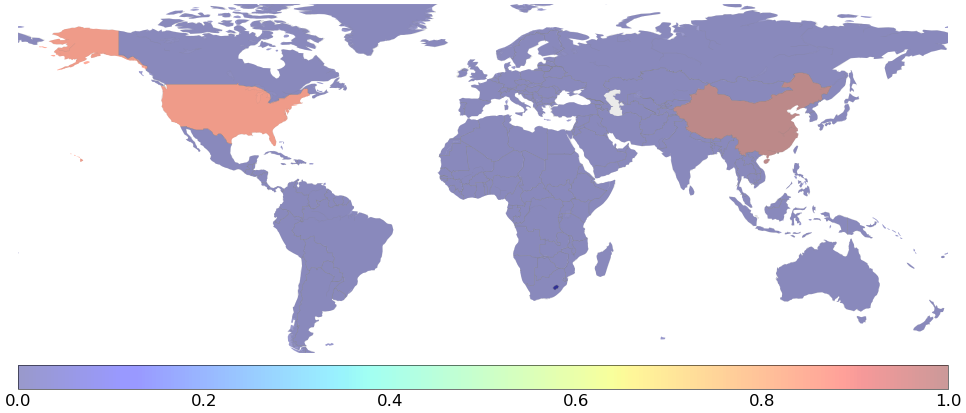

In [145]:
# draw overall distribution in the global space
try:
    from mpl_toolkits.basemap import Basemap
except Exception as e:
    logging.error(
        "you need to install Basemap from here"
        " https://github.com/matplotlib/basemap"
    )
    raise e
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import math
%matplotlib inline
map_data = r"G:\python\global_map_data\ne_110m_admin_0_countries"
my_dpi = 48
# collected from above markdown table
overall_country_ip_count_dict = {
    'US': 4673,
    'CN': 18277,
    'TW': 0,
}

country_3_to_2_dict = {
    'nor': 'no',
    'fra': 'fr',
    'cyn': 'cy',
    'sol': 'so',
    'kos': 'ko',
}
fig = plt.figure(figsize=(1200/my_dpi, 800/my_dpi), dpi=my_dpi)
ax = fig.add_subplot(111)
# Make the background map
m=Basemap(llcrnrlon=-180, llcrnrlat=-55,urcrnrlon=180,urcrnrlat=80)
m.drawmapboundary(fill_color='white', linewidth=0)
m.fillcontinents(color='grey', alpha=0.2)
m.drawcoastlines(linewidth=0.1, color="grey")
m.drawcountries(color='grey')
m.readshapefile(
    map_data,
    'units',
    drawbounds=False,
    linewidth=0.1,
    color='grey',
)
patches = []
patch_color_list = []
tmp_country_set = set()

# merge tw with cn, as tw is part of CN
overall_country_ip_count_dict['CN'] += overall_country_ip_count_dict['TW']
overall_country_ip_count_dict['TW'] = overall_country_ip_count_dict['CN']

#color the global map according to the number of ip's in each country
for country_poly, country_info in zip(m.units, m.units_info):
    country_code = country_info['ISO_A2'].lower()
    if country_code == '-99':
        country_code = country_info['ADM0_A3'].lower()
        if country_code == '-99':
            print(country_info)
        else:
            country_code = country_3_to_2_dict[country_code]
    ip_count = overall_country_ip_count_dict.get(country_code.upper(), None)
    if  ip_count is None:
        logging.info('no ips found for country %s', country_code)
        ip_count = 0
    patch = Polygon(np.array(country_poly), True)
    patches.append(patch)
    patch_color_list.append(ip_count)
    tmp_country_set.add(country_code)
min_color = min(patch_color_list)
max_color = max(patch_color_list)
max_min_gap = max_color - min_color
salt = 1
max_min_gap_log = math.log(max_min_gap + salt, 10)
new_patch_color_list = []
for color in patch_color_list:
    new_color = math.log(color - min_color + salt, 10) / max_min_gap_log
    new_patch_color_list.append(new_color)
patch_color_list = new_patch_color_list
p = PatchCollection(patches, alpha=0.4, cmap='jet')
p.set_array(np.array(patch_color_list))
ax.add_collection(p)
# add colorbar
cb = fig.colorbar(
    p,
    ax=ax,
    orientation='horizontal',
    pad=0.02,
    aspect=40,
)
cb.ax.tick_params(labelsize=25)
cb.ax.tick_params(axis='x', which='both', bottom=False)
result_file = os.path.join(
    result_dir,
    'overall_ip_country_distribution_heatmap.pdf',
)
plt.savefig(
    result_file,
    bbox_inches='tight',
)
plt.show()

IPs collected  are mainly located in China and a small part is located in US 

In [146]:
#calculate the distribution of IPs by province of CN 

# read item from JSON file and initialize all dicts
file_path = r'C:\Users\何宁远\OneDrive\桌面\getip2.json'
with open(file_path, 'r') as file:
    data = json.load(file)
province_to_start_time_dict = {}
province_to_end_time_dict = {}
province_to_date_dict = defaultdict(set)
province_to_ip_dict = defaultdict(set)
province_request_count_dict = defaultdict(int)

# filter those items while item["Response"] is None and item["Response"]["country"] == "CN"
filtered_data = [item for item in data if item["Response"] is not None and item["Response"]["country"] == "CN"]
# iterate over each JSON item and get dicts related to province
for item in filtered_data :
    timestamp = item['Timestamp']
    response = item['Response']
    ip = response['ip']
    city = response['city']
    province = response['region']
    country = response['country']
    loc = response['loc']
    org = response['org']
    timezone = response['timezone']
    readme = response['readme']
    date_str = datetime.datetime.fromtimestamp(timestamp).strftime('%Y%m%d')
    start_time = province_to_start_time_dict.get(province, None)
    end_time = province_to_end_time_dict.get(province, None)
    if start_time is None or timestamp < start_time:
        province_to_start_time_dict[province] = timestamp
    if end_time is None or timestamp > end_time:
        province_to_end_time_dict[province] = timestamp
    province_to_date_dict.setdefault(province, set()).add(date_str)
    province_to_ip_dict.setdefault(province, set()).add(ip)
    province_request_count_dict[province] += 1
    province_request_count_dict["overall"] += 1

logging.info('loaded done')




2024-03-06 20:18:57,989 INFO loaded done


In [155]:
# output distribution of IPs in each province of China
rows = []
for province in sorted(province_to_ip_dict):
    start_time = province_to_start_time_dict[province]
    end_time = province_to_end_time_dict[province]
    start_date = datetime.datetime.fromtimestamp(start_time)
    end_date = datetime.datetime.fromtimestamp(end_time)
    rows.append([
        province,
        "{start_date} - {end_date}".format(
            start_date=start_date.strftime(date_format),
            end_date=end_date.strftime(date_format),
        ),
        len(province_to_date_dict[province]),
        len(province_to_ip_dict[province]),
        province_request_count_dict[province]

    ])
    
columns = ['province', 'Period', '# Days', '# IPs', '# Probes']
result_df = pd.DataFrame(data=rows, columns=columns)
display(Markdown('## Infiltration Periods of Proxy provinces'))
display(result_df)
latex_str = result_df.to_latex(buf=None, header=False, index=False)
print(latex_str)


## Infiltration Periods of Proxy provinces

,province,Period,# Days,# IPs,# Probes
0,Anhui,12/07/2023 - 12/24/2023,18,6623,9551
1,Beijing,12/08/2023 - 12/22/2023,3,3,3
2,Chongqing,12/07/2023 - 12/24/2023,18,774,1114
3,Fujian,12/07/2023 - 12/24/2023,18,1143,1488
4,Guangdong,12/14/2023 - 12/14/2023,1,1,1
5,Guangxi,12/07/2023 - 12/24/2023,18,499,684
6,Hebei,12/07/2023 - 12/24/2023,18,1843,2853
7,Henan,12/07/2023 - 12/24/2023,18,159,206
8,Hubei,12/07/2023 - 12/24/2023,18,307,431
9,Hunan,12/07/2023 - 12/24/2023,18,493,831


\begin{tabular}{llrrr}
\toprule
\midrule
Anhui & 12/07/2023 - 12/24/2023 & 18 & 6623 & 9551 \\
Beijing & 12/08/2023 - 12/22/2023 & 3 & 3 & 3 \\
Chongqing & 12/07/2023 - 12/24/2023 & 18 & 774 & 1114 \\
Fujian & 12/07/2023 - 12/24/2023 & 18 & 1143 & 1488 \\
Guangdong & 12/14/2023 - 12/14/2023 & 1 & 1 & 1 \\
Guangxi & 12/07/2023 - 12/24/2023 & 18 & 499 & 684 \\
Hebei & 12/07/2023 - 12/24/2023 & 18 & 1843 & 2853 \\
Henan & 12/07/2023 - 12/24/2023 & 18 & 159 & 206 \\
Hubei & 12/07/2023 - 12/24/2023 & 18 & 307 & 431 \\
Hunan & 12/07/2023 - 12/24/2023 & 18 & 493 & 831 \\
Jiangsu & 12/07/2023 - 12/24/2023 & 18 & 2151 & 3220 \\
Jiangxi & 12/12/2023 - 12/24/2023 & 13 & 569 & 678 \\
Liaoning & 12/07/2023 - 12/24/2023 & 18 & 129 & 173 \\
Shaanxi & 12/07/2023 - 12/24/2023 & 18 & 670 & 1070 \\
Shanghai & 12/13/2023 - 12/19/2023 & 2 & 2 & 2 \\
Sichuan & 12/07/2023 - 12/24/2023 & 18 & 430 & 966 \\
Zhejiang & 12/07/2023 - 12/24/2023 & 18 & 2481 & 3395 \\
\bottomrule
\end{tabular}



The table above is sorted by the first letter of the pinyi of province.We collect a tiny amount of IPs in three municipalities.

2024-03-06 20:19:06,181 INFO no ips found for country Gansu
2024-03-06 20:19:06,278 INFO no ips found for country Guizhou


C:\Windows\Temp\ipykernel_16364\4059168247.py:42: MatplotlibDeprecationWarning: Passing the closed parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  patch = Polygon(np.array(province_poly), True)


2024-03-06 20:19:06,279 INFO no ips found for country Guizhou
2024-03-06 20:19:06,283 INFO no ips found for country Hainan
2024-03-06 20:19:06,285 INFO no ips found for country Hainan
2024-03-06 20:19:06,286 INFO no ips found for country Hainan
2024-03-06 20:19:06,287 INFO no ips found for country Hainan
2024-03-06 20:19:06,288 INFO no ips found for country Hainan
2024-03-06 20:19:06,288 INFO no ips found for country Hainan
2024-03-06 20:19:06,290 INFO no ips found for country Hainan
2024-03-06 20:19:06,293 INFO no ips found for country Hainan
2024-03-06 20:19:06,295 INFO no ips found for country Hainan
2024-03-06 20:19:06,298 INFO no ips found for country Hainan
2024-03-06 20:19:06,301 INFO no ips found for country Hainan
2024-03-06 20:19:06,302 INFO no ips found for country Hainan
2024-03-06 20:19:06,305 INFO no ips found for country Hainan
2024-03-06 20:19:06,308 INFO no ips found for country Hainan
2024-03-06 20:19:06,309 INFO no ips found for country Hainan
2024-03-06 20:19:06,310

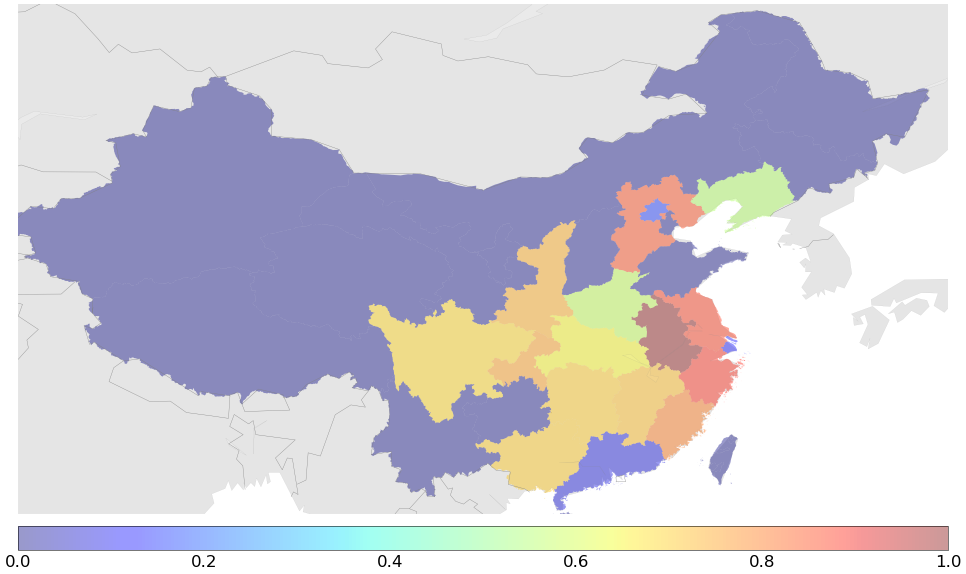

In [148]:
# draw overall distribution in China
overall_province_ip_count_dict = {}
for province in province_to_ip_dict:
    overall_province_ip_count_dict[province] = len(province_to_ip_dict[province])

map_data = r'C:\Users\何宁远\OneDrive\桌面\China_Map\gadm36_CHN_1'
my_dpi = 48
fig = plt.figure(figsize=(1200/my_dpi, 800/my_dpi), dpi=my_dpi)
ax = fig.add_subplot(111)
# Make the background map
m=Basemap(llcrnrlon=74,llcrnrlat=20,urcrnrlon=136,urcrnrlat=54)
m.drawmapboundary(fill_color='white', linewidth=0)
m.fillcontinents(color='grey', alpha=0.2)
m.drawcoastlines(linewidth=0.1, color="grey")
m.drawcountries(color='grey')
m.readshapefile(
    map_data,
    'units',
    drawbounds=False,
    linewidth=0.1,
    color='grey',
)
m.readshapefile(
    r'C:\Users\何宁远\OneDrive\桌面\Taiwan_Map\gadm36_TWN_1',
    'TWN',
    drawbounds=False,
    linewidth=0.1,
    color='grey',

)

patches = []
patch_color_list = []
tmp_country_set = set()

# merge tw with cn, as tw is part of CN
for province_poly, province_info in zip(m.units+m.TWN, m.units_info+m.TWN_info):
    province_name = province_info['NAME_1']
    ip_count = overall_province_ip_count_dict.get(province_name,None)
    if  ip_count is None:
        logging.info('no ips found for country %s', province_name)
        ip_count = 0
    patch = Polygon(np.array(province_poly), True)
    patches.append(patch)
    patch_color_list.append(ip_count)
    tmp_country_set.add(province_name)
min_color = min(patch_color_list)
max_color = max(patch_color_list)
max_min_gap = max_color - min_color
salt = 1
max_min_gap_log = math.log(max_min_gap + salt, 10)
new_patch_color_list = []
for color in patch_color_list:
    new_color = math.log(color - min_color + salt, 10) / max_min_gap_log
    new_patch_color_list.append(new_color)
patch_color_list = new_patch_color_list
p = PatchCollection(patches, alpha=0.4, cmap='jet')
p.set_array(np.array(patch_color_list))
ax.add_collection(p)
# add colorbar
cb = fig.colorbar(
    p,
    ax=ax,
    orientation='horizontal',
    pad=0.02,
    aspect=40,
)
cb.ax.tick_params(labelsize=25)
cb.ax.tick_params(axis='x', which='both', bottom=False)
result_file = os.path.join(
    result_dir,
    'overall_ip_province_distribution_heatmap.pdf',
)
plt.savefig(
    result_file,
    bbox_inches='tight',
)
plt.show()

IPs collected are mainly located in the hinterland ,especially in the Jiangzhe area,including Jiangsu,Zhejiang and Anhui.Heebi also has a considerable amount of IPs.In the border area,we can barely collect IPs.